Saving style.jpg to style (2).jpg
Saving content.jpg to content (1).jpg
0 6713413.5
50 513262.84375
100 263225.0625
150 179106.9375
200 139152.5
250 115677.6640625


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

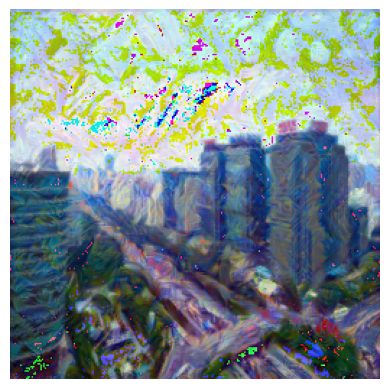

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# upload images
uploaded = files.upload()

loader = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

def load_image(path):
    image = Image.open(path).convert("RGB")
    image = loader(image).unsqueeze(0)
    return image.to(device)

content = load_image("content.jpg")
style = load_image("style.jpg")

# load pretrained model
vgg = models.vgg19(pretrained=True).features.to(device).eval()

for param in vgg.parameters():
    param.requires_grad = False

content_layer = '21'
style_layers = ['0','5','10','19','28']

def get_features(x, model):
    features = {}
    for name, layer in model._modules.items():
        x = layer(x)
        if name == content_layer:
            features[name] = x
        if name in style_layers:
            features[name] = x
    return features

def gram_matrix(tensor):
    b,c,h,w = tensor.size()
    tensor = tensor.view(c,h*w)
    gram = torch.mm(tensor, tensor.t())
    return gram

content_features = get_features(content, vgg)
style_features = get_features(style, vgg)

style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_layers}

target = content.clone().requires_grad_(True)

optimizer = optim.Adam([target], lr=0.003)

style_weight = 1e6
content_weight = 1

steps = 300

for i in range(steps):

    target_features = get_features(target, vgg)

    content_loss = torch.mean((target_features[content_layer] -
                               content_features[content_layer])**2)

    style_loss = 0

    for layer in style_layers:

        target_feature = target_features[layer]
        target_gram = gram_matrix(target_feature)

        style_gram = style_grams[layer]

        _,c,h,w = target_feature.shape

        layer_loss = torch.mean((target_gram-style_gram)**2)

        style_loss += layer_loss/(c*h*w)

    total_loss = content_weight*content_loss + style_weight*style_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if i % 50 == 0:
        print(i,total_loss.item())

# show final image
image = target.clone().detach().cpu().squeeze(0)
image = transforms.ToPILImage()(image)

plt.imshow(image)
plt.axis("off")